# Branches: what we fetched

`data/seed/v3/branches.csv`, written by `scripts/fetch_branches.py`: Bedashing's 24 UAE
lounges from its own store locator, each matched to its Google Maps listing for location,
rating and review count. Provenance and caveats: `data/seed/v3/SOURCES.md`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 140)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "grid.color": "#888",
                     "axes.edgecolor": "#999", "font.size": 9})
# Fixed categorical order (dataviz default palette, slots 1-5), largest emirate first.
EMIRATES = ["Abu Dhabi", "Dubai", "Sharjah", "Ras Al Khaimah", "Fujairah"]
COLOR = dict(zip(EMIRATES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

b = pd.read_csv(ROOT / "data/seed/v3/branches.csv")
b[["branch_id", "emirate", "name", "rating", "review_count", "status", "pin_offset_km"]]

,branch_id,emirate,name,rating,review_count,status,pin_offset_km
0,al-ain,Abu Dhabi,Bedashing Beauty Lounge Al Ain,4.7,1332,OPERATIONAL,8.372
1,al-barsha,Dubai,Bedashing Beauty Lounge Al Barsha,4.6,753,OPERATIONAL,0.119
2,al-dhafra,Abu Dhabi,Bedashing Beauty Lounge - Al Dhafra,4.5,359,OPERATIONAL,0.001
3,al-falah,Abu Dhabi,Bedashing Beauty Lounge Al Falah,4.6,951,OPERATIONAL,1.714
4,al-jada,Sharjah,Bedashing Beauty Lounge Al Jada,4.5,620,OPERATIONAL,0.033
5,al-maqta,Abu Dhabi,Bedashing Beauty Lounge Al Maqta,4.6,1295,OPERATIONAL,0.351
6,al-taif-mall,Fujairah,Bedashing Beauty Lounge Al Taif Mall,4.7,499,OPERATIONAL,0.049
7,baniyas,Abu Dhabi,Bedashing Beauty Lounge Baniyas,4.5,697,OPERATIONAL,2.471
8,city-walk,Dubai,Bedashing Beauty Lounge City Walk,4.6,857,OPERATIONAL,0.002
9,delma,Abu Dhabi,Bedashing Beauty Lounge Delma,4.6,676,OPERATIONAL,0.926


## 1. Is the data complete?

In [2]:
pd.Series({
    "lounges": len(b),
    "matched to a Google listing": int(b.place_id.notna().sum()),
    "OPERATIONAL": int((b.status == "OPERATIONAL").sum()),
    "duplicate place_id": int(b.place_id.duplicated().sum()),
    "missing rating": int(b.rating.isna().sum()),
    "missing review count": int(b.review_count.isna().sum()),
    "fetched": ", ".join(b.fetched_at.unique()),
}, name="value").to_frame()

,value
lounges,24
matched to a Google listing,24
OPERATIONAL,24
duplicate place_id,0
missing rating,0
missing review count,0
fetched,2026-10-08


## 2. Summary numbers

In [3]:
overall = b[["rating", "review_count"]].describe().T
overall["total"] = [None, b.review_count.sum()]
overall.round(2)

,count,mean,std,min,25%,50%,75%,max,total
rating,24.0,4.61,0.12,4.4,4.5,4.6,4.62,4.9,NaN
review_count,24.0,878.92,486.58,215.0,615.5,755.0,1017.50,2465.0,21094.0


In [4]:
by_emirate = (b.groupby("emirate")
    .agg(lounges=("branch_id", "size"),
         rating_mean=("rating", "mean"), rating_min=("rating", "min"), rating_max=("rating", "max"),
         reviews_median=("review_count", "median"), reviews_total=("review_count", "sum"))
    .reindex(EMIRATES))
by_emirate["share_of_reviews"] = by_emirate.reviews_total / b.review_count.sum()
by_emirate.round(2)

,lounges,rating_mean,rating_min,rating_max,reviews_median,reviews_total,share_of_reviews
emirate,,,,,,,
Abu Dhabi,15,4.61,4.4,4.9,834.0,15096,0.72
Dubai,5,4.62,4.5,4.8,753.0,3505,0.17
Sharjah,2,4.55,4.5,4.6,611.0,1222,0.06
Ras Al Khaimah,1,4.50,4.5,4.5,772.0,772,0.04
Fujairah,1,4.70,4.7,4.7,499.0,499,0.02


In [5]:
# Google shows ratings to one decimal, so 24 lounges collapse onto a handful of values.
b.rating.value_counts().sort_index().rename("lounges").to_frame().T

rating,4.4,4.5,4.6,4.7,4.8,4.9
lounges,1,7,10,3,1,2


## 3. Ratings

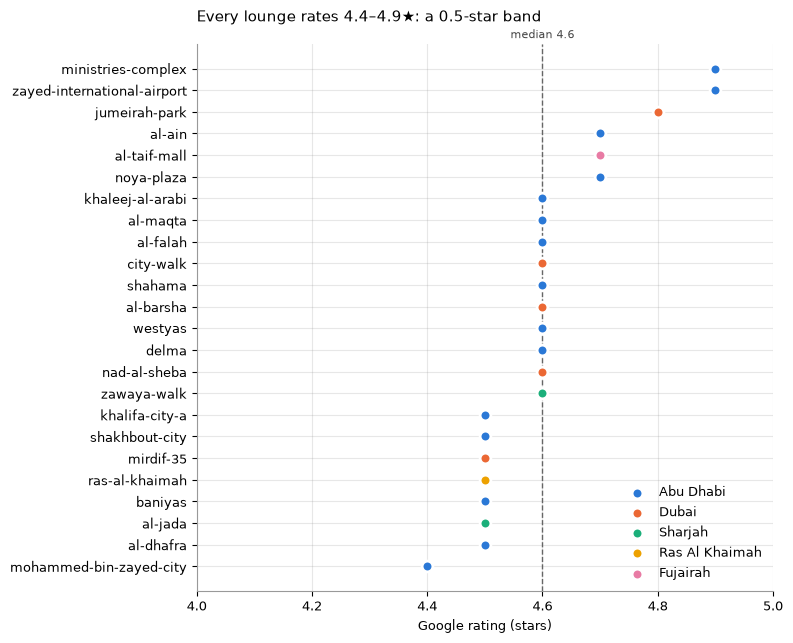

In [6]:
s = b.sort_values(["rating", "review_count"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.set_yticks(s.index, s.branch_id)   # numeric rows keep the rating order across emirates
for e in EMIRATES:
    m = s.emirate == e
    ax.scatter(s.rating[m], s.index[m], s=60, color=COLOR[e], edgecolor="white", lw=2,
               label=e, zorder=3)
ax.axvline(b.rating.median(), color="#666", lw=1, ls="--")
ax.text(b.rating.median(), 1.01, f"median {b.rating.median():.1f}", transform=ax.get_xaxis_transform(),
        ha="center", fontsize=8, color="#444")
ax.set_xlim(4.0, 5.0)
ax.set_xlabel("Google rating (stars)")
ax.set_title("Every lounge rates 4.4–4.9★: a 0.5-star band", loc="left", pad=16)
ax.legend(loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

## 4. Review counts

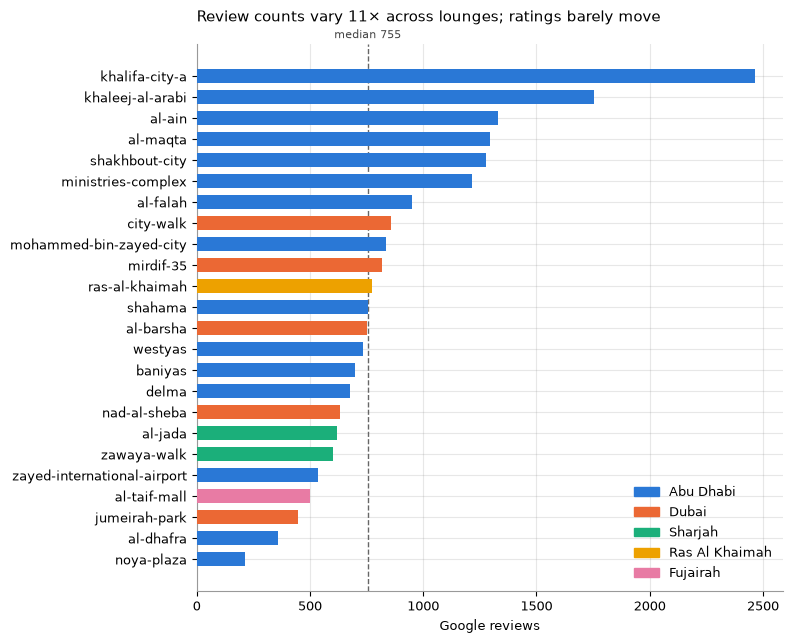

In [7]:
from matplotlib.patches import Patch

s = b.sort_values("review_count")
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(s.branch_id, s.review_count, color=[COLOR[e] for e in s.emirate], height=0.7, zorder=3)
ax.axvline(b.review_count.median(), color="#666", lw=1, ls="--")
ax.text(b.review_count.median(), 1.01, f"median {b.review_count.median():,.0f}",
        transform=ax.get_xaxis_transform(), ha="center", fontsize=8, color="#444")
ax.set_xlabel("Google reviews")
ax.set_title(f"Review counts vary {b.review_count.max() / b.review_count.min():.0f}× "
             "across lounges; ratings barely move", loc="left", pad=16)
ax.legend(handles=[Patch(color=COLOR[e], label=e) for e in EMIRATES],
          loc="lower right", frameon=False)
plt.tight_layout(); plt.show()

## 5. Do busier lounges rate differently?

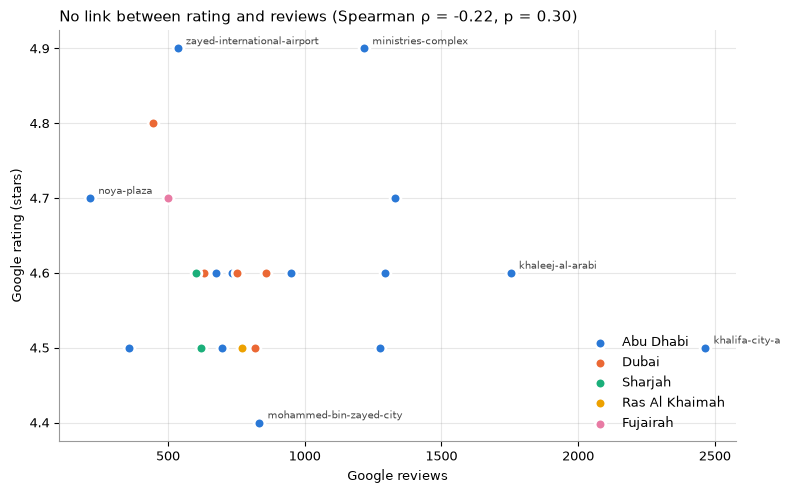

In [8]:
from scipy.stats import spearmanr

fig, ax = plt.subplots(figsize=(8, 5))
for e in EMIRATES:
    m = b.emirate == e
    ax.scatter(b.review_count[m], b.rating[m], s=60, color=COLOR[e], edgecolor="white", lw=2,
               label=e, zorder=3)
for r in b.itertuples():
    if r.review_count > 1500 or r.rating >= 4.9 or r.rating <= 4.4 or r.review_count < 300:
        ax.annotate(r.branch_id, (r.review_count, r.rating), xytext=(6, 3),
                    textcoords="offset points", fontsize=7, color="#444")
ax.set_xlabel("Google reviews")
ax.set_ylabel("Google rating (stars)")
rho, p = spearmanr(b.rating, b.review_count)
ax.set_title(f"No link between rating and reviews (Spearman ρ = {rho:.2f}, p = {p:.2f})", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 6. Locations: store locator vs Google
The store locator lists which lounges exist; Google gives the pin. The script matched by name,
so a large offset means the locator's pin is wrong, not the match (addresses agree).

In [9]:
b.loc[b.pin_offset_km > 0.5, ["branch_id", "emirate", "pin_offset_km", "locator_address", "address"]] \
    .sort_values("pin_offset_km", ascending=False)

,branch_id,emirate,pin_offset_km,locator_address,address
19,shahama,Abu Dhabi,15.908,"Abu Dhabi – Al Shahama Rd , Abu Dhabi","Abu Dhabi - Al Shahama Road Deerfields Mall, S..."
0,al-ain,Abu Dhabi,8.372,"Villa 14, Hamdan Bin Mohammad St. , Al Markani...",Villa 18 Hamdan Bin Mohammad St - Al Markaniya...
16,nad-al-sheba,Dubai,4.841,"Nad Al Sheba Mall, Nad Al Sheba 3 - Dubai, Sho...",5959+RVJ - Nad Al Sheba - Nad Al Sheba 3 - Dub...
11,khaleej-al-arabi,Abu Dhabi,2.564,"Opposite Al Bateen Gardens, Next to Mubarak Bi...","Villa 487, Next to Mubarak Bin Muhamad School ..."
7,baniyas,Abu Dhabi,2.471,"Villa D, Baniyas East 8, Opposite to Lulu Hype...",Villa 4 Number 22 - Al Suqa Street - Bani Yas ...
3,al-falah,Abu Dhabi,1.714,"Al Falah Village 4, 1D Branch, Abu Dhabi",Abu Dhabi - Al Falah - 1D - Abu Dhabi - United...
23,zayed-international-airport,Abu Dhabi,1.398,"International Airport - Midfield Terminal, Abu...",Midfield Terminal - International Airport - RU...
18,ras-al-khaimah,Ras Al Khaimah,1.120,"Villa 3, Sheikh Rashid Bin Saeed Al Maktoum Rd...",Villa 66 Sheikh Rashid Bin Saeed Al Maktoum Rd...
9,delma,Abu Dhabi,0.926,"Shop 1 & 2 Kim Tower, Delma St (Al Nahayan Are...","Shop 1 & 2, Kim Tower - Delma Street - behind ..."
13,ministries-complex,Abu Dhabi,0.872,"Shop No - 3, ICT Building, Khalifa Park (Minis...","Shop No. 3, ICT Building, Khalifa Park ,Minist..."


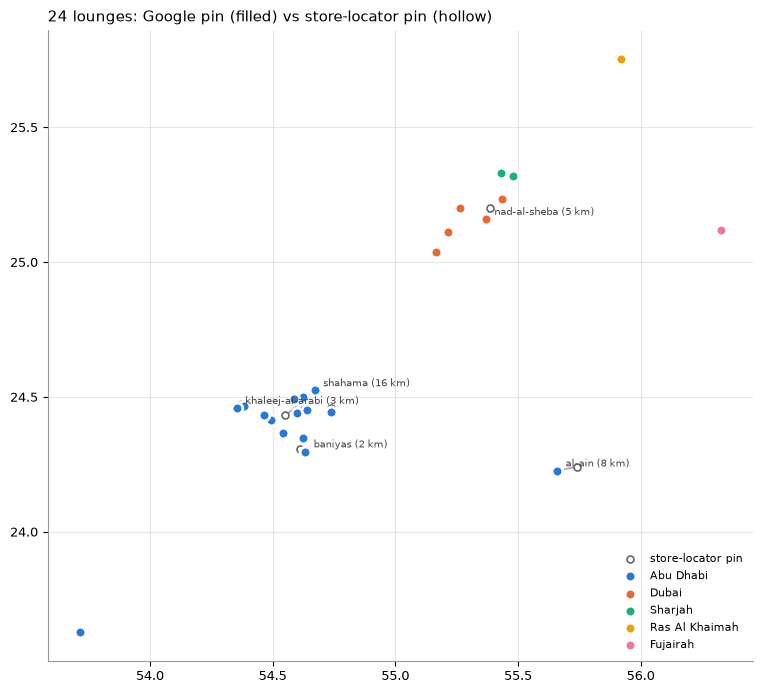

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
for r in b.itertuples():
    ax.plot([r.locator_lng, r.lng], [r.locator_lat, r.lat], color="#999", lw=1, zorder=1)
ax.scatter(b.locator_lng, b.locator_lat, s=25, facecolor="white", edgecolor="#666", lw=1.2,
           label="store-locator pin", zorder=2)
for e in EMIRATES:
    m = b.emirate == e
    ax.scatter(b.lng[m], b.lat[m], s=60, color=COLOR[e], edgecolor="white", lw=2, label=e, zorder=3)
for r in b[b.pin_offset_km > 2].itertuples():
    ax.annotate(f"{r.branch_id} ({r.pin_offset_km:.0f} km)", (r.lng, r.lat), xytext=(6, 3),
                textcoords="offset points", fontsize=7, color="#444")
ax.set_aspect(1 / 0.91)   # cos(24.5°): keep distances honest
ax.set_title("24 lounges: Google pin (filled) vs store-locator pin (hollow)", loc="left")
ax.legend(frameon=False, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## 7. Findings

**Coverage is complete.** All 24 lounges matched a Google listing, all OPERATIONAL, no gaps
in rating or review count. 15 are in Abu Dhabi (incl. Al Ain, Al Dhafra), 5 in Dubai, 2 in
Sharjah, 1 each in Ras Al Khaimah and Fujairah.

**Ratings carry almost no signal.**
- Mean 4.61★, median 4.6★, spread 4.4–4.9★ (std 0.12). Google shows one decimal, so 24 lounges
  fall on just 6 values; 17 of 24 sit at 4.5 or 4.6.
- Emirate averages are within 0.15★ of each other (4.55–4.70).
- Outliers: ministries-complex and zayed-international-airport at 4.9★;
  mohammed-bin-zayed-city lowest at 4.4★.
- A 0.1★ step is the rounding unit, so most "differences" between lounges are not
  distinguishable. On the old rubric's 4.0–5.0 scale this band is 0.4–0.9: rating moves a
  branch's composite by at most ~0.12.

**Review counts carry far more spread.**
- Median 755, mean 879, range 215 (noya-plaza) to 2,465 (khalifa-city-a): 11×. 21,094 in total.
- Abu Dhabi holds 72% of all reviews (15 lounges); Dubai 17% (5 lounges).
- Abu Dhabi's villa-format lounges lead (khalifa-city-a, khaleej-al-arabi, al-ain,
  al-maqta, shakhbout-city: all above 1,200). The mall and newer units trail (noya-plaza 215,
  al-dhafra 359, jumeirah-park 447).
- Review count is a rough proxy for cumulative footfall, but it confounds volume with
  **age**: we don't know opening dates, so a young lounge looks small.

**Rating and review count are unrelated** (Spearman ρ = −0.22, p = 0.30, n = 24). Busy lounges
don't rate worse in any way this sample can detect.

**Locations: the store locator's pins are unreliable.** 10 of 24 are more than 0.5 km from the
Google pin. Shahama is 15.9 km off (the real lounge is in Deerfields Mall), Al Ain 8.4 km,
Nad Al Sheba 4.8 km. In every case the street addresses agree, so Google's pin is the one to use.

**Implications for the model**
1. Drop rating as a scored signal, or score it relative to nearby competitors (Task 4
   fetches their ratings) instead of on an absolute 4.0–5.0 scale.
2. Consider review count as a demand/traction signal, with the age caveat stated.
3. Use Google pins for every distance computation.

## 8. Examples
Two lounges: one where the store locator and Google agree (**city-walk**) and the largest
disagreement (**shahama**, 16 km). Orange: Google's pin; grey: the store locator's.

In [11]:
from IPython.display import Markdown, display
from scripts.spot_maps import points, show

bi = b.set_index("branch_id")
for bid in ["city-walk", "shahama"]:
    r = bi.loc[bid]
    display(Markdown(f"### {bid}: {r['name']}\n"
                     f"- **Google:** {r.rating}★, {int(r.review_count):,} reviews, {r.status}; {r.address}\n"
                     f"- **Store locator address:** {r.locator_address}\n"
                     f"- **Pins apart:** {r.pin_offset_km:.2f} km"))
    pins = [points([{"lat": r.lat, "lng": r.lng, "label": f"Google: {r['name']}", "r": 120}], (235, 104, 52)),
            points([{"lat": r.locator_lat, "lng": r.locator_lng, "label": "store-locator pin", "r": 120}], (120, 120, 120))]
    mid_lat, mid_lng = (r.lat + r.locator_lat) / 2, (r.lng + r.locator_lng) / 2
    display(show(pins, mid_lat, mid_lng, zoom=15 if r.pin_offset_km < 1 else 10.5, height=380))

### city-walk: Bedashing Beauty Lounge City Walk
- **Google:** 4.6★, 857 reviews, OPERATIONAL; City Walk Dubai - Dubai - الوصل - دبي - United Arab Emirates
- **Store locator address:** 18A-06 Al Raha Street, City Walk
- **Pins apart:** 0.00 km

### shahama: Bedashing Beauty Lounge
- **Google:** 4.6★, 757 reviews, OPERATIONAL; Abu Dhabi - Al Shahama Road Deerfields Mall, Shop No 419B - الباهية - الباهية القديمة - أبو ظبي - United Arab Emirates
- **Store locator address:** Abu Dhabi – Al Shahama Rd , Abu Dhabi
- **Pins apart:** 15.91 km